# Imports

In [1]:
import numpy as np
import math
from typing import Any
from IPython.display import display, Latex, HTML
from fractions import Fraction
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d



<h1> List of symbols </h1>

In [2]:
# --------------------------Nominal data---------------------------------------

m: int                      # Number of phases [-]
P_2: float                  # Nominal output mechanical power [W]
U: float                    # Voltage of the DC-link [V]
n_r: float                  # Mechanical speed of the rotor [rpm]
f: float                    # Fundamental frequency of the fed current [Hz]
p: int                      # Number of pole pairs [-]
T_env: float                # Temperature of the environment [°C]
T_w_m: float                # Temperature of windings and magnets [°C]
# --------------------------Main dimensions---------------------------------------

B_delta_1: float            # Peak fundamental air gap flux density [T]
A_s1rms: float              # Linear current density  [A/m]
T_n: float                  # Nominal torque [Nm]
eta: float                  # Efficiency of the motor [-]
eta_delta: float            # Efficiency of the motor in the air gap [-]
tau_p: float                # Pole pitch [m]
cos_phi_delta: float        # Power factor in the air gap [-]
D: float                    # Diameter of the stator stack [m]
l: float                    # Length of the stator stack [m]
D_o: float                  # Outer diameter of the stator stack [m]
D_i: float                  # Rotor inner diameter [m]
D_r: float                  # Rotor outer diameter [m]
aspect_ratio: float         # Ratio between the stack length and pole pitch [-]
D_o_D_ratio: float          # Ratio to obtain the outer stator diameter [-]
delta: float                # Air gap length [-]
# --------------------------Determination of permanent magnet operating point---------------------------------------

B_r: float                  # Remanence of the permanent magnet @ T_w_m [T]
H_c: float                  # Coercivity of the permanent magnet @ T_w_m [A/m]
mi_o: float                 # Magnetic permeability of air [H/m]
mi_rm: float                 # Relative permeability of permanent magnet @ T_w_m [H/m]
k_c: float                  # Carter's factor for air gap [-]
k_sat: float                # Saturation factor [-]
delta_1: float              # Increased air-gap that takes k_c and k_sat into account [-]
alpha_m: float              # Width of the magnet [°]
B_delta_m1: float           # Fundamental space component of the air-gap flux density of the magnet [T]
B_delta_m: float            # Air-gap flux density of the magnet[T]
h_m: float                  # Thickness of the magnet [m]
H_m: float                  # Permanent magnet operating point [A/m]
#---------------------------Choice of the slot/pole combination-----------------------------------------------------

Q_s: int                    # Number of slots [-]
y: int                      # Coil pitch [-]
q: float                    # Number of slots per pole per phase [-]
a_q: float                  # Apparent number of slots per pole per phase [-]
b_q: float                  # Apparent number of poles [-]
tau_p_slots: float          # Number of slots per pole pitch [-]
t: int                      # Greatest common denominator - number of revolutions in phasor diagram [-]
Q_t: int                    # Number of voltage phasors in the phasor diagram with different phase angles [-]
alpha: float                # Electrical angle between two slots [°]
alpha_apparent: float       # Apparent electrical angle between  two slots [°]
f_d: float                  # Distribution factor - ratio of the actual vector sum and algebraic sum phase winding MMF [-]
f_p: float                  # Pitch factor [-]
f_w: float                  # Winding factor for first harmonic [-]
C_t: float                  # "Goodness" factor for surpressing the cogging torque [-]
p_1: int                    # Number of force pole pairs [-]

#---------------------------Stator slot and winding design-----------------------------------------------------

f_fill: float               # Slot fill factor [-]
bo: float                   # Slot opening width [m]
ho: float                   # Slot opening height [m]
rc: float                   # Curvature radius at the bottom of the slot [m]
bt: float                   # Tooth width [m]
hs: float                   # Total slot height [m]
bs: float                   # Slot width [m]
h1: float                   # Height of the first slot segment [m]
h2: float                   # Height of the second slot segment [m]
h3: float                   # Height of the third slot segment [m]
b1: float                   # Width between the first and second segment [m]
b2: float                   # Width between the second and third segment [m]
Phi_m: float                # Flux per pole pitch [Wb]
U_f: float                  # RMS phase voltage with a Y winding configuration [V]
E: float                    # RMS Back-EMF phase voltage [V]
z: float                    # Number of conductor per phase connected in series [-]
z_slot: float               # Number of conductors per slot [-]
a: int                      # Number of parallel paths [-]
cos_phi: float              # Power factor [-]
I: float                    # RMS phase current [A]
J: float                    # Current density [A/mm^2]
q_c: float                  # Required cross-section of a conductor [mm^2]
S_Cu: float                 # Total cross-sectional area of copper in the slot [mm^2]
S_Slot: float               # Total area of the slot [mm^2]

#------------------------Design of the magnetic circuit------------------------------------------------------
k_fe: float                 # Stacking factor [-]
tau_s: float                # Slot pitch [m]
delta_kc: float             # Air-gap length for calculating k_c [m]
V_delta: float              # Air-gap MMF drop [A]
B_t_I: float                # Real flux density in the 1st section of the tooth [T]
B_t_I_apparent: float       # Apparent flux density in the 1st section of the tooth [T]
H_t_I: float                # Field strength in the 1st section of the tooth [A/m]
V_t_I: float                # MMF drop in section I [A]
B_t_II_0: float             # Real flux density in the 2nd section of the tooth at y = 0 [T]
B_t_II_apparent: float      # Apparent flux density in the 2nd section of the tooth at y = 0 [T]
H_t_II_0: float             # Field strength in the 2nd section of the tooth at y = 0 [A/m]
B_t_II_half: float          # Real flux density in the 2nd section of the tooth at y = h1 / 2 [T]
B_t_II_half_apparent: float # Apparent flux density in the 2nd section of the tooth at y = h1 / 2 [T]
H_t_II_half: float          # Field strength in the 2nd section of the tooth at y = h1 / 2 [A/m]
B_t_II_h1: float            # Real flux density in the 2nd section of the tooth at y = h1 [T]
B_t_II_h1_apparent: float   # Apparent flux density in the 2nd section of the tooth at y = h1 [T]
H_t_II_h1: float            # Field strength in the 2nd section of the tooth at y = h1 [A/m]
V_t_II: float               # MMF drop in section II [A]
B_t_III: float              # Real flux density in the 3rd section of the tooth [T]
B_t_III_apparent: float     # Apparent flux density in the 3rd section of the tooth [T]
H_t_III: float              # Field strength in the 3rd section of the tooth [A/m]
V_t_III: float              # MMF drop in section III [A]
b_t_I: float                # Tooth width in section I [m]
b_t_II_0: float             # Tooth width in section II at y = 0 [m]
b_t_II_half: float          # Tooth width in section II at y = h1 / 2 [m]
b_t_II_h1: float            # Tooth width in section II at y = h1 [m]
b_t_III: float              # Tooth width in section III [m]
V_t: float                  # MMF drop in stator tooth [A]
h_ys: float                 # Height of the stator yoke [m]
h_yr: float                 # Height of the rotor yoke [m]
B_ys: float                 # Maximum flux density in stator yoke [T]
B_yr: float                 # Maximum flux density in rotor yoke [T]
V_ys: float                 # Stator yoke MMF drop [A]
V_yr: float                 # Rotor yoke MMF drop [A]
H_ys: float                 # Field strength in stator yoke [A/m]
H_yr: float                 # Field strength in rotor yoke [A/m]
K_ys: float                 # Coefficient of field strength in stator yoke [-]
K_yr: float                 # Coefficient of field strength in rotor yoke [-]
l_ys: float                 # Average length of the flux lines in stator yoke [m]
l_yr: float                 # Average length of the flux lines in rotor yoke [m]
#------------------------Losses and efficiency------------------------------------------------------
sigma_copper: float         # Conductivity of copper [MS/m]
l_ew: float                 # Length of the end winding [m]
R_theta: float              # Resistivity of copper @ \theta [ohm]
P_Cu: float                 # Winding (copper) losses [W]
A: float                    # Constant for the l_ew calculation [-]
B: float                    # Constant for the l_ew calculation [mm]
Pc: float                   # Core losses [W]






y: int # Coil pitch [-]
q: float # Number of slots per pole per phase [-]
# --------------------------Magnet losses---------------------------------------
N_seg_tan: int # Number of tangential segments [-]
N_seg_ax: int # Number of axial segments [-]
lm_seg: float # Axial length of each segment [m]
bo_marked: float # Total width of the area where the slot opening has an impact on the rotor surface flux density [-]
beta: float  # Parameter for calculation [-]
u: float #Parameter for calculation [-]
alpha_1_v: float #Parameter for calculation [-]
ro_magnet: float #Electrical Resistivity of the magnet [Ohm m]
sigma_m: float #Conductivity of the magnet [S/m]
b_m_seg: float #Width of a tangential magnet segment
l_m_seg: float #Length of a axial magnet segment
B_v: float #Harmonic amplitude of the flux density on the magnet surface [T]
f_mv: float #Frequency of the flux density variation in the magnets caused by the stator slotting and the rotor rotation [Hz]
omega_mv: float #Rotational frequency of the flux density variation in the magnets caused by the stator slotting and the rotor rotation [rad/s]
delta_mv: float # Depth below the surface of the magnet at which the current density has fallen to 1/e = 0.368 [m]
Psi_mv: float # Flux of each travelling wave on the rotor surface [Vs]
E_mv: float # EMF induced in the permanent magnet for each harmonic [V]
S_m_ax_v: float # Cross-sectional area of the axial route carrying the eddy currents [m**2]
S_m_tan_v: float # Cross-sectional area of the tangential route carrying the eddy currents [m**2]
R_mv: float # Resistance of the eddy current path [Ohm]
Z_mv: float # Impedance of the eddy current path [Ohm]
I_mv: float # RMS eddy current in the magnet [A]
# --------------------------Magnetizing inductance------------------------------
L_m : float # Magnetizing inductance [H]
L_sigma_sl: float # Slot leakage inductance [H]
lambda_t: float # Specific permeance of the top coil [H]
lambda_b: float # Specific permeance of the bottom coil [H]
lambda_tb: float # Specific permeance of the mutual flux linkage between the top and bottom coil sides
k_sl: float # Phase shift coefficient due to short pitching of the coils [-]
k_t_1: float # Parameter for permeance calculation [-]
k_t_2: float # Parameter for permeance calculation [-]
k_t_2: float # Parameter for permeance calculation [-]
t_1: float # Parameter for permeance calculation [-]
t_2: float # Parameter for permeance calculation [-]
t_3: float # Parameter for permeance calculation [-]
L_sigma_tt: float # Tooth tip leakage inductance [H]
lambda_tt: float # Specific permeance of the tooth tip path [H]
delta_double_marked: float # Equivalent air-gap length which includes Carter's coefficient due to stator slotting
delta_triple_marked: float # Equivalent air-gap length whithout Carter's coefficient



<h1> Nominal data </h1>

In [32]:
m = 3                       # TODO
P_2 = 5000                  # TODO
U = 60                      # TODO
n_r = 1500                  # TODO
p = 3                       # TODO
f = n_r * p / 60            # TODO
T_env = 40                  # TODO
T_w_m = 120                 # TODO

display(Latex(rf"$m = {m} \,$"))
display(Latex(rf"$P_{{2}} = {P_2} \, W $"))
display(Latex(rf"$U_{{dc}} = {U} \, V$"))
display(Latex(rf"$n_{{rm}} = {n_r} \, rpm$"))
display(Latex(rf"$p = {p} \, $"))
display(Latex(rf"$f_{{n}} = {f} \, Hz$"))
display(Latex(rf"$T_{{env}} = {T_env} \, \textdegree C$"))
display(Latex(rf"$T_{{wm}} = {T_w_m} \, \textdegree C$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h1> MAIN DIMENSIONS </h1>

In [4]:
B_delta_1 = 1.1             # TODO
A_s1rms = 30000             # TODO
eta = 0.915                 # TODO
tau_p = 0.06                # TODO
D_i = 0.038                 # TODO
cos_phi_delta = 0.92        # TODO
D_o_D_ratio = 1.85          # TODO
delta = 1.1e-3              # TODO

T_n = round(P_2 * 30 / (n_r * math.pi), 2)
display(Latex(rf'$T_{{n}} =  {T_n}\,\mathrm{{Nm}}$'))

eta_delta = round(eta / (0.25 + 0.75 * eta), 2)
display(Latex(rf'$\eta_{{\delta}} =  {eta_delta}$'))

D = round(tau_p * (2 * p) / math.pi,2)
display(Latex(rf'$D =  {D}\,\mathrm{{m}}$'))

l = round(P_2/((math.pi**2)/(math.sqrt(2)*p)*B_delta_1*A_s1rms*f*eta_delta*cos_phi_delta*D**2),2)
display(Latex(rf'$l =  {l}\,\mathrm{{m}}$'))

D_o = round(D*D_o_D_ratio,2)
display(Latex(rf'$D_{{o}} =  {D_o}\,\mathrm{{m}}$'))


display(Latex(rf'$B_{{\delta 1}} =  {B_delta_1}\,\mathrm{{T}}$'))
display(Latex(rf'$A_{{s1rms}} =  {A_s1rms}\,\mathrm{{A/m}}$'))
display(Latex(rf'$\eta = {eta} $'))
display(Latex(rf'$\tau_p = {tau_p} \, \mathrm{{m}}$'))
display(Latex(rf'$D_{{i}} = {D_i} \, \mathrm{{m}}$'))
display(Latex(rf'$\cos\,{{\varphi_{{\delta}}}} =  {cos_phi_delta}$'))
display(Latex(rf'$D_{{o}}/D =  {D_o_D_ratio} $'))
display(Latex(rf'$\delta =  {delta*1e3}\,\mathrm{{mm}}$'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h1> DETERMINATION OF THE PERMANENT MAGNET OPERATING POINT </h1>

In [5]:
B_r = 1.11                  # TODO
H_c = 835000                # TODO
k_c = 1.02                  # TODO
k_sat = 1.2                 # TODO
alpha_m = 130               # TODO

mi_0 = 4*math.pi*10**(-7)

delta_1 = round(delta * k_c * k_sat, 5)
display(Latex(rf"$\delta'  =  {delta_1*1e3}\,\mathrm{{mm}}$"))

mi_rm = round(B_r/(H_c*mi_0),2)
display(Latex(rf'$\mu_{{rm}} =  {mi_rm}$'))

B_delta_m1 = round(B_delta_1*cos_phi_delta,2)
display(Latex(rf'$B_{{\delta \mathrm{{m1}}}} =  {B_delta_m1}\,\mathrm{{T}}$'))

B_delta_m = round((math.pi*B_delta_m1)/(4*math.sin(math.radians(alpha_m/2))),2)
display(Latex(rf'$B_{{\delta \mathrm{{m}}}} =  {B_delta_m}\,\mathrm{{T}}$'))

h_m = round((delta_1*mi_rm)/(B_r/B_delta_m - 1), 5)
display(Latex(rf'$h_{{m}} =  {h_m*1e3:.2f}\,\mathrm{{mm}}$'))

H_m = round(-(B_delta_m*delta_1)/(mi_0*h_m), 0)
display(Latex(rf'$H_{{m}} =  {H_m}\,\mathrm{{\frac{{A}}{{m}}}}$'))




<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h1> CHOICE OF THE SLOT/POLE COMBINATION </h1>

In [6]:
Q_s = 27                     #TODO
y = 3                        #TODO

q = Q_s/(2*p*m)
q_frac = Fraction(q)

display(Latex(rf'$q =  {q_frac}$'))

a_q = q_frac.numerator
b_q = q_frac.denominator

tau_p_slots = Q_s/(2*p)
display(Latex(rf'$\tau_{{p}} =  {tau_p_slots}$'))

t = math.gcd(Q_s,p)
display(Latex(rf'$t =  {t}$'))

Q_t = round(Q_s/t)
display(Latex(rf'$Q_{{t}} =  {Q_t}$'))

alpha = (p*360)/Q_s
display(Latex(rf'$\alpha =  {alpha}\degree$'))

alpha_apparent = 180/(m*a_q)
display(Latex(rf"$\alpha' =  {alpha_apparent}\degree$"))

f_d = round((math.sin(math.radians(a_q*alpha_apparent/2)))/(a_q*math.sin(math.radians(alpha_apparent/2))),3)
display(Latex(rf'$f_{{z}} =  {f_d}$'))

f_p = round(math.sin((y*math.pi)/(tau_p_slots*2)),3)
display(Latex(rf'$f_{{t}} =  {f_p}$'))

f_w = round(f_d*f_p,3)
display(Latex(rf'$f_{{n}} =  {f_w}$'))

C_t = round((2*p*Q_s)/math.lcm(Q_s,2*p))
display(Latex(rf'$C_{{t}} =  {C_t}$'))

p_1 = round((2*p)/b_q)
display(Latex(rf"$p' =  {p_1}$"))



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h1> STATOR SLOT AND WINDING DESIGN </h1>

In [7]:
f_fill = 0.4                # TODO
a = 1                       # TODO
J = 5                       # TODO
cos_phi = 0.93              # TODO
Phi_m = D * l * B_delta_m1 / p
display(Latex(rf'$\Phi_{{m}} =  {Phi_m*1e3:.2f}\,\mathrm{{mWb}}$'))

U_f = U/(math.sqrt(2)*math.sqrt(3))
display(Latex(rf'$U_{{ph,rms}} =  {U_f:.1f}\,\mathrm{{V}}$'))

E = round((0.98*U_f*cos_phi_delta),2)
display(Latex(rf'$E =  {E}\,\mathrm{{V}}$'))

z = round(E/(2.22*Phi_m*f_w*f))


z_slot = round((z*m*a)/Q_s)


if z_slot % 2 == 0:                             # In case of a two-layer winding z_slot should be an even number so that all coils have the same number of turns
    pass
else:
    a = 2
    z_slot = z_slot*a

test = (2*p)/(a*b_q)                            # Constraint for fractional slot winding

if test.is_integer():
    pass
    z = z_slot * Q_s / (m * a)
else:
    raise ValueError('Check fractional slot winding constraint!')


display(Latex(rf'$z =  {z}$'))
display(Latex(rf'$z_{{slot}} =  {z_slot}$'))

Phi_m = E/(2.22*z*f*f_w)
display(Latex(rf'$\Phi_{{m}} =  {Phi_m*1e3:.2f}\,\mathrm{{mWb}}$'))

B_delta_m1 = round((Phi_m*p)/(D*l),2)
display(Latex(rf'$B_{{\delta \mathrm{{m1}}}} =  {B_delta_m1}\,\mathrm{{T}}$'))

B_delta_m = round((math.pi*B_delta_m1)/(4*math.sin(math.radians(alpha_m/2))),2)
display(Latex(rf'$B_{{\delta m}} =  {B_delta_m}\,\mathrm{{T}}$'))

h_m_ = round((delta_1*mi_rm)/(B_r/B_delta_m - 1),2)
display(Latex(rf'$h_{{m}} =  {h_m * 1e3}\,\mathrm{{mm}}$'))

I = round(P_2/(3*U_f*eta*cos_phi),2)
display(Latex(rf'$I_{{rms}} =  {I}\,\mathrm{{A}}$'))

q_c = round(I/(a*J))
display(Latex(rf'$q_{{c}} =  {q_c}\,\mathrm{{mm^{{2}}}}$'))

S_cu = q_c*z_slot
display(Latex(rf'$S_{{cu}} =  {S_cu}\,\mathrm{{mm^{{2}}}}$'))

S_ut = S_cu/f_fill
display(Latex(rf'$S_{{ut}} =  {S_ut}\,\mathrm{{mm^{{2}}}}$'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h2> Matlab script for slot dimensions</h2>

In [8]:
# INPUT DATA
# All input and output dimensions are in meters

bo = 3.5e-3     # Slot opening width
ho = 0.64e-3    # Slot opening height
rc2 = 1.2e-3    # Curvature radius at the bottom of the slot
D = D           # Stator bore diameter
Qs = Q_s        # Number of stator slots
bt = 7e-3       # Tooth width
hs = 27.3e-3    # Total slot height

# -------------------------------------------------------------
Rs = D / 2
alphao = 2 * math.asin(0.5 * bo / Rs)   # slot opening in rad
thetas = 2 * math.pi / Qs

x1 = bo / 2
y1 = Rs * math.cos(alphao * 0.5)
x2 = x1
y2 = y1 + ho

deltar = bt / (2 * math.sin(thetas * 0.5))
a1 = math.cos(thetas * 0.5) ** 2
b1 = 2 * (deltar * math.sin(thetas * 0.5) ** 2 - Rs * math.cos(alphao * 0.5) - ho)
c1 = (bo ** 2) * 0.25 + (Rs * math.cos(alphao * 0.5) + ho) ** 2 - deltar ** 2 * math.sin(thetas * 0.5) ** 2

q1 = (-b1 + math.sqrt(b1 ** 2 - 4 * a1 * c1)) / (2 * a1)
rc1 = math.sqrt(x2 ** 2 + (q1 - y2) ** 2)

x3 = 0.5 * math.sin(thetas) * (q1 - deltar)
y3 = -x3 * math.tan(thetas * 0.5) + q1

bs = 2 * (Rs + hs) * math.tan(thetas * 0.5) - bt / math.cos(thetas * 0.5)  # slot width
gama = math.atan(2 * (Rs - deltar + hs) / bs)

p2 = bs * 0.5 - rc2 / math.tan(gama * 0.5)
q2 = Rs + hs

y4 = (q2 + p2 * math.tan(thetas * 0.5) + deltar * math.tan(thetas * 0.5) ** 2) / \
     (1 + math.tan(thetas * 0.5) ** 2)

x4 = (q2 - y4) / math.tan(thetas * 0.5) + p2

x5 = bs * 0.5 - rc2 / math.tan(gama * 0.5)
y5 = Rs + hs

alpha1 = math.atan(x3 / (q1 - y3))
alpha2 = math.atan(x2 / (q1 - y2))
alpha3 = math.atan((bs * 0.5 - x5) / rc2)

S11 = (rc1 ** 2) * alpha1 - 0.5 * rc1 ** 2 * math.sin(2 * alpha1) \
    - (rc1 ** 2) * alpha2 + 0.5 * rc1 ** 2 * math.sin(2 * alpha2)

S21 = -rc2 * (bs * 0.5 - x5) + rc2 ** 2 * alpha3

A = 2 * (y4 - y3) / (x4 - x3)
B = y3 - y5 + (-x3 + 0.5 * bs) * (y4 - y3) / (x4 - x3)
C = (-S21 + S11 - 0.5 * bs * y5 - x3 * y3
     + (x3 + 0.5 * bs) * (y3 - (y4 - y3) / (x4 - x3) * x3))

x6 = (-B + math.sqrt(B ** 2 - 4 * A * C)) / (2 * A)
y6 = y3 + (y4 - y3) / (x4 - x3) * (x6 - x3)

# -------------------------------------------------------------
# OUTPUT DATA
# Slot dimensions

h1 = y3 - y2
h2 = y6 - y3
h3 = y5 - y6

b1 = 2 * x3
b2 = 2 * x6
# bs already defined

# Area of the top half of the slot (mm^2)
S1 = (S11 + (x3 + x6) * (y6 - y3)) * 1e6

# Area of the bottom half of the slot (mm^2)
S2 = (S21 + 0.5 * (bs + 2 * x6) * (y5 - y6)) * 1e6

# Total slot area
Sslot = S1 + S2

display(Latex(rf'$h_{{1}} =  {h1*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$h_{{2}} =  {h2*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$h_{{3}} =  {h3*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$b_{{1}} =  {b1*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$b_{{2}} =  {b2*10**3}\,\mathrm{{mm^{{2}}}}$'))
display(Latex(rf'$b_{{utora}} =  {bs*10**3}\,\mathrm{{mm^{{2}}}}$'))

display(Latex(rf'$S_{{utora}} =  {Sslot}\,\mathrm{{mm^{{2}}}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h1> DESIGN OF THE MAGNETIC CIRCUIT </h1>

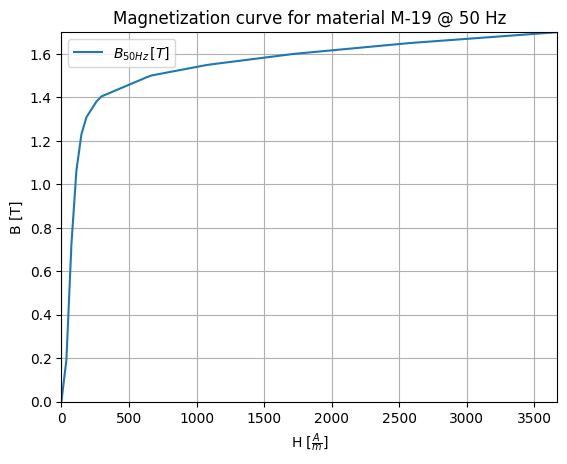

In [9]:
# Data for magnetization curve is taken from:
# https://ocw.mit.edu/courses/6-685-electric-machines-fall-2013/64bf1faf0a973d9607334321dd252794_MIT6_685F13_ps03data.pdf

Data_points = 100                               #TODO

# Data for magnetization at 50 Hz
B_50Hz = np.array([
    0.0,0.10, 0.20, 0.40, 0.70, 1.00,
    1.20, 1.30, 1.40, 1.50, 1.55,
    1.60, 1.65, 1.70
])                                              #TODO

H_50Hz = np.array([
    0.0,26.5, 37.8, 52.4, 71.9, 99.3,
    136.0, 176.0, 279.0, 659.0, 1084.0,
    1718.0, 2577.0, 3670.0
])                                              #TODO

H_interp = np.linspace(0.0, H_50Hz[-1], Data_points)
B_interp = np.interp(H_interp,H_50Hz,B_50Hz)

plt.plot(H_interp, B_interp, label=r'$B_{{50Hz}} \, [T]$')

plt.xlim([0.0,max(H_interp)])
plt.ylim([0.0,max(B_interp)])
plt.xlabel(r"H [$\frac{A}{m}]$")
plt.ylabel("B [T]")
plt.legend(loc='best')
plt.grid()
plt.title("Magnetization curve for material M-19 @ 50 Hz")
plt.show()

<h2> Air-gap MMF </h2>

In [10]:
k_fe = 0.97             #TODO

tau_s = round((D*math.pi)/Q_s,3)
display(Latex(rf'$\tau_{{s}} =  {tau_s}\,\mathrm{{m}}$'))

delta_kc = delta + h_m/mi_rm
display(Latex(rf'$\delta_{{kc}} =  {delta_kc*1e3:.2f}\,\mathrm{{mm}}$'))

k_c = round(tau_s/(tau_s-(2*bo/math.pi)*(math.atan(bo/(2*delta_kc))-(delta_kc/bo)*math.log(1+(bo/(2*delta_kc))**2))),4)
display(Latex(rf'$k_{{c}} =  {k_c}$'))

V_delta = round(k_c * delta * B_delta_m/mi_0,2)
display(Latex(rf'$V_{{\delta}} =  {V_delta}\,\mathrm{{A}}$'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h2> Tooth MMF drop </h2>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

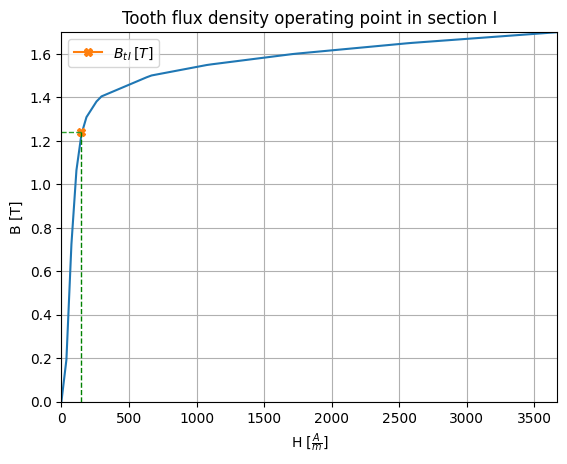

<IPython.core.display.Latex object>

In [11]:
# Section I
b_t_I = tau_s - bo
display(Latex(rf'$b_{{tI}} =  {b_t_I*1e3}\,\mathrm{{mm}}$'))

B_t_I_apparent = round((B_delta_m*tau_s)/(k_fe*b_t_I),2)
display(Latex(rf"$B_{{tI}}' =  {B_t_I_apparent}\,\mathrm{{T}}$"))

if B_t_I_apparent >= 1.8:
    plt.figure()
    k_t1 = tau_s/(k_fe*b_t_I) - 1
    plt.plot(H_interp,B_interp, label = 'Magnetization curve' )
    B_t1 = B_t_I_apparent - H_interp*k_t1*mi_0
    plt.plot(H_interp,B_t1, label = 'Tooth density in teeth')
    res = np.where(np.sign(B_t1-B_interp)[:-1] != np.sign(B_t1-B_interp)[1:])[0]         

    B_pres = round(B_t1[res[0]],2)                                 
    H_pres = round(H_interp[res[0]],2)

    display(Latex(rf"$B_{{tI}}' =  {B_pres}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{tI}} =  {H_pres}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.xlabel(r"H [$\frac{A}{m}]$")                            
    plt.ylabel("B [T]")

    plt.legend()                                  
    plt.grid()                                    
    plt.title("Tooth flux density operating point in section I")
    plt.show()

    B_t_I = B_pres
    H_t_I = H_pres

else:
    B_t_I = B_t_I_apparent
    res = np.where(np.sign(B_t_I-B_interp[:-1]) != np.sign(B_t_I-B_interp[1:]))[0]
    H_t_I = round(H_interp[res[0]],2)

    plt.plot(H_interp, B_interp)

    plt.xlim([0.0,max(H_interp)])
    plt.ylim([0.0,max(B_interp)])
    plt.xlabel(r"H [$\frac{A}{m}]$")
    plt.ylabel("B [T]")
    plt.grid()

    plt.plot(H_t_I,B_t_I, marker = "X", label=r'$B_{{t\,I}} \, [T]$')
    plt.plot([0,H_t_I],[B_t_I,B_t_I],linestyle = "dashed",linewidth = "1")
    plt.plot([H_t_I,H_t_I], [0, B_t_I], linestyle = "dashed",linewidth = "1", color = "green")
    display(Latex(rf"$B_{{tI}} =  {B_t_I}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{tI}} =  {H_t_I}\,\mathrm{{\frac{{A}}{{m}}}}$'))
    plt.title("Tooth flux density operating point in section I")
    plt.legend(loc='best')
    plt.show()

V_t_I = round(H_t_I * ho,4)
display(Latex(rf'$V_{{tI}} =  {V_t_I}\,\mathrm{{A}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

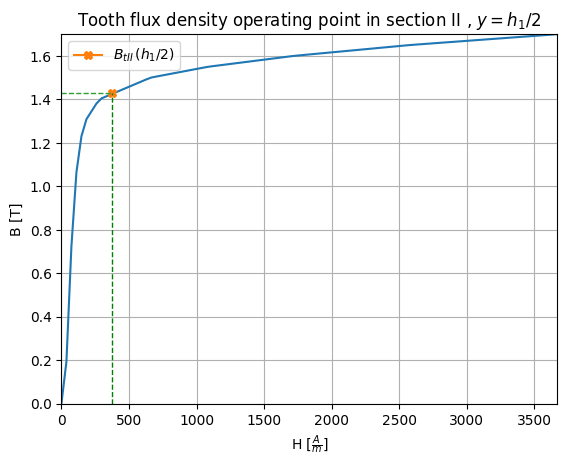

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

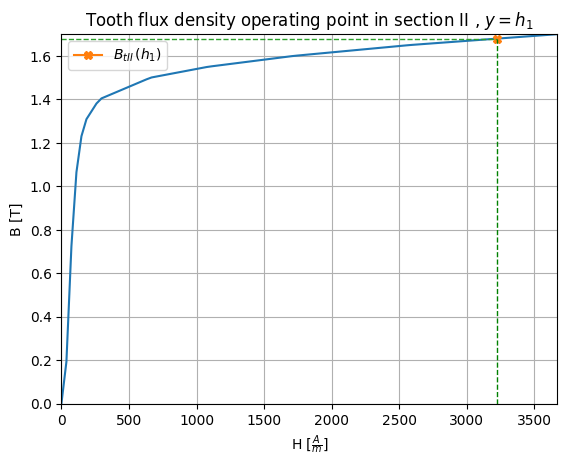

<IPython.core.display.Latex object>

In [12]:
# Section II
# y = 0
# ---------------------------
B_t_II_0 = B_t_I
H_t_II_0 = H_t_I


display(Latex(rf"$B_{{tII}}\, (0) =  {B_t_II_0}\,\mathrm{{T}}$"))
display(Latex(rf'$H_{{tII}}\, (0) =  {H_t_II_0}\,\mathrm{{\frac{{A}}{{m}}}}$'))


display(HTML("<br><br><br>"))
# y = h1 / 2
#----------------------------
b_t_II_half = (b_t_I+bt)/2
display(Latex(rf"$b_{{tII}}  \, (h_1 / 2) =  {b_t_II_half*1e3}\,\mathrm{{mm}}$"))
B_t_II_half_apparent = round((B_delta_m*tau_s)/(k_fe*b_t_II_half),2)
display(Latex(rf"$B_{{tII}}' \, (h_1 / 2) =  {B_t_II_half_apparent}\,\mathrm{{T}}$"))


if B_t_II_half_apparent >= 1.8:
    plt.figure()
    k_t2 = tau_s/(k_fe*b_t_II_half) - 1
    plt.plot(H_interp,B_interp, label = 'Magnetization curve' )
    B_t2_dio2 = B_t_II_half_apparent - H_interp*k_t2*mi_0
    plt.plot(H_interp,B_t2_dio2, label = 'Indukcija u zubu')
    res = np.where(np.sign(B_t2_dio2-B_interp)[:-1] != np.sign(B_t2_dio2-B_interp)[1:])[0]

    B_pres = round(B_t2_dio2[res[0]],2)
    H_pres = round(H_interp[res[0]],2)

    display(Latex(rf"$B_{{t1}}' =  {B_pres}\,\mathrm{{T}}$"))                 
    display(Latex(rf'$H_{{t1}} =  {H_pres}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.xlabel(r"H [$\frac{A}{m}]$")
    plt.ylabel("B [T]")

    plt.legend()
    plt.grid()
    plt.title("Tooth flux density operating point in section II , r'$y = h_1 / 2$'")
    plt.show()                                    

    B_t_II_half = B_pres
    H_t_II_half = H_pres

else:
    B_t_II_half = B_t_II_half_apparent
    res = np.where(np.sign(B_t_II_half-B_interp[:-1]) != np.sign(B_t_II_half-B_interp[1:]))[0]
    H_t_II_half = round(H_interp[res[0]],2)
    display(Latex(rf"$B_{{tII}}\, (h_1 / 2) =  {B_t_II_half}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{tII}}\, (h_1 / 2) =  {H_t_II_half}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.plot(H_interp, B_interp)

    plt.xlim([0.0,max(H_interp)])
    plt.ylim([0.0,max(B_interp)])
    plt.xlabel(r"H [$\frac{A}{m}]$")
    plt.ylabel("B [T]")
    plt.grid()

    plt.plot(H_t_II_half,B_t_II_half, marker = "X", label = r"$B_{tII} \, ( h_1 / 2 )$")
    plt.plot([0,H_t_II_half],[B_t_II_half,B_t_II_half],linestyle = "dashed",linewidth = "1")
    plt.plot([H_t_II_half,H_t_II_half], [0, B_t_II_half], linestyle = "dashed",linewidth = "1", color = "green")
    plt.legend(loc = "best")
    plt.title("Tooth flux density operating point in section II , $y = h_1 / 2$")
    plt.show()

# y = h1
#----------------------------
display(HTML("<br><br><br>"))

b_t_II_h1 = bt           
display(Latex(rf'$b_{{tII}} \, ( h_1 )=  {b_t_II_h1*10**3}\,\mathrm{{mm}}$'))

B_t_II_h1_apparent = round((B_delta_m*tau_s)/(k_fe*b_t_II_h1),2)
display(Latex(rf"$B_{{tII}}' \, ( h_1 ) =  {B_t_II_h1_apparent}\,\mathrm{{T}}$"))

if B_t_II_h1_apparent >= 1.8:
    plt.figure()
    k_t3 = tau_s/(k_fe*b_t_II_h1) - 1
    plt.plot(H_interp,B_interp, label = 'Krivulja magnetiziranja' )
    B_t2_dio3 = B_t_II_h1_apparent - H_interp*k_t3*mi_0
    plt.plot(H_interp,B_t2_dio3, label = 'Indukcija u zubu')
    res = np.where(np.sign(B_t2_dio3-B_interp)[:-1] != np.sign(B_t2_dio3-B_interp)[1:])[0]

    B_pres = round(B_t2_dio3[res[0]],2)
    H_pres = round(H_interp[res[0]],2)

    display(Latex(rf"$B_{{t1}}' =  {B_pres}\,\mathrm{{T}}$"))                 
    display(Latex(rf'$H_{{t1}} =  {H_pres}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.xlabel(r"H [$\frac{A}{m}]$")
    plt.ylabel("B [T]")

    plt.legend()
    plt.grid()
    plt.title("Tooth flux density operating point in section II , $y = h_1$")
    plt.show()                                    

    B_t_II_h1 = B_pres
    H_t_II_h1 = H_pres

else:
    B_t_II_h1 = B_t_II_h1_apparent                          
    res = np.where(np.sign(B_t_II_h1-B_interp[:-1]) != np.sign(B_t_II_h1-B_interp[1:]))[0]       
    H_t_II_h1 = round(H_interp[res[0]],2)                  
    display(Latex(rf"$B_{{tII}} \, ( h_1 ) =  {B_t_II_h1}\,\mathrm{{T}}$"))
    display(Latex(rf'$H_{{tII}} \, ( h_1 ) =  {H_t_II_h1}\,\mathrm{{\frac{{A}}{{m}}}}$'))

    plt.plot(H_interp, B_interp)                  

    plt.xlim([0.0,max(H_interp)])                 
    plt.ylim([0.0,max(B_interp)])
    plt.xlabel(r"H [$\frac{A}{m}]$")              
    plt.ylabel("B [T]")
    plt.grid()
    plt.plot(H_t_II_h1,B_t_II_h1, marker = "X", label=r"$B_{tII} \, ( h_1 )$")
    plt.legend(loc = "best")
    plt.plot([0,H_t_II_h1],[B_t_II_h1,B_t_II_h1],linestyle = "dashed",linewidth = "1")
    plt.plot([H_t_II_h1,H_t_II_h1], [0, B_t_II_h1], linestyle = "dashed",linewidth = "1", color = "green")
    plt.title("Tooth flux density operating point in section II , $y = h_1$")
    plt.show()


V_t_II = round((h1/6) * (H_t_II_0 + 4*H_t_II_half + H_t_II_h1),2)
display(Latex(rf'$V_{{tII}} =  {V_t_II}\,\mathrm{{A}}$'))


In [13]:
# Section III
B_t_III = B_t_II_h1
H_t_III = H_t_II_h1
b_t_III = bt
display(Latex(rf"$B_{{tIII}}' =  {B_t_III}\,\mathrm{{T}}$"))
display(Latex(rf'$H_{{tIII}} =  {H_t_III}\,\mathrm{{\frac{{A}}{{m}}}}$'))
display(Latex(rf"$b_{{tIII}} = {b_t_III*1e3}\,\mathrm{{mm}}$"))
V_t_III = round(H_t_III * (h2+h3),2)
display(Latex(rf'$V_{{tIII}} =  {V_t_III}\,\mathrm{{A}}$'))

V_t = round(V_t_I + V_t_II + V_t_III,2)
display(Latex(rf'$V_{{t}} =  {V_t}\,\mathrm{{A}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h2> Stator and rotor yoke MMF drop </h2>

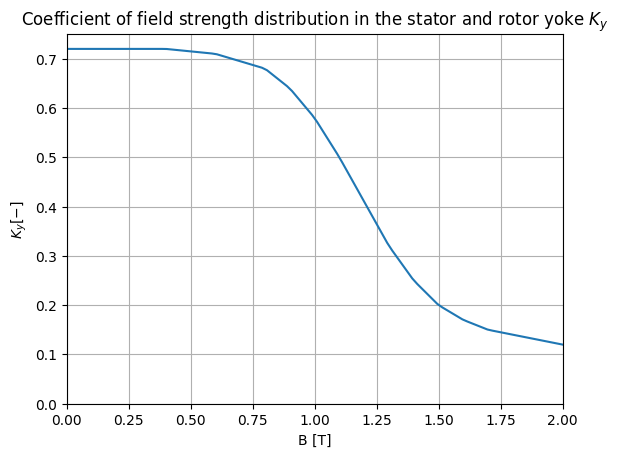

In [14]:
# Stator and rotor yoke coefficients
B_ky = np.array([
    0.0, 0.2, 0.4, 0.6, 0.8,
    0.9, 1.0, 1.1, 1.2, 1.3,
    1.4, 1.5, 1.6, 1.7, 1.8,
    1.9, 2.0
])                                  # TODO

Ky = np.array([
    0.72, 0.72, 0.72, 0.71, 0.68,
    0.64, 0.58, 0.50, 0.41, 0.32,
    0.25, 0.20, 0.17, 0.15, 0.14,
    0.13, 0.12
])                                  # TODO

B_ky_interp = np.linspace(0.0,2.0,100)
Ky_interp = np.interp(B_ky_interp,B_ky,Ky)
Ky_from_B = interp1d(
    B_ky,
    Ky,
    kind='linear',          # 'cubic' or 'pchip' optional
    fill_value="extrapolate"
)
plt.plot(B_ky_interp,Ky_interp)
plt.xlabel("B [T]")
plt.ylabel("$K_{y} [-]$")
plt.xlim([0.0,max(B_ky)])
plt.ylim([0.0,0.75])
plt.title("Coefficient of field strength distribution in the stator and rotor yoke $K_y$")
plt.grid()
plt.show()

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

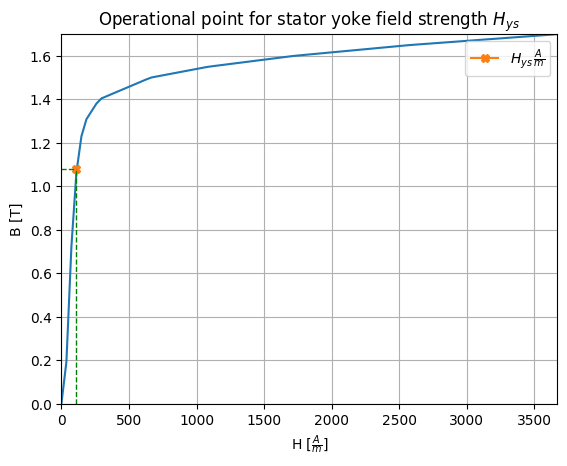

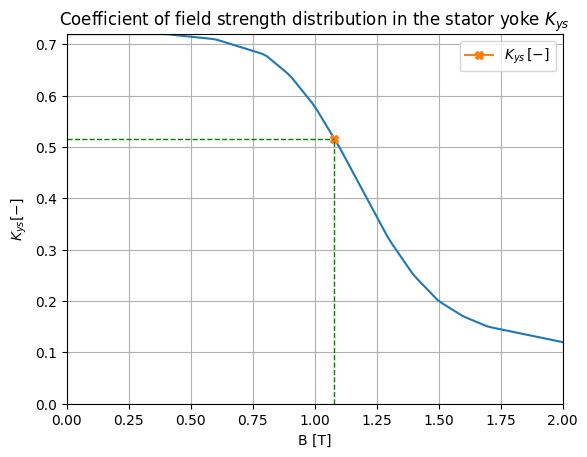

In [15]:
# Stator MMF drop
h_ys = round((D_o-(D+2*hs))/2,4)
display(Latex(rf'$h_{{ys}} =  {h_ys*1e3}\,\mathrm{{mm}}$'))

B_ys = round(Phi_m/(2*k_fe*h_ys*l),2)
display(Latex(rf'$B_{{ys}} =  {B_ys}\,\mathrm{{T}}$'))

res = np.where(np.sign(B_ys-B_interp[:-1]) != np.sign(B_ys-B_interp[1:]))[0]
H_ys = round(H_interp[res[0]],2)
display(Latex(rf'$H_{{ys}} =  {H_ys}\,\mathrm{{\frac{{A}}{{m}}}}$'))

K_ys = Ky_from_B(B_ys)
display(Latex(rf'$K_{{ys}} =  {K_ys}$'))

l_ys = round(((D_o-h_ys)*math.pi)/(2*p) + 0.6*h_ys,2)
display(Latex(rf'$l_{{ys}} =  {l_ys}\,\mathrm{{m}}$'))

V_ys = round(H_ys*l_ys*K_ys,2)
display(Latex(rf'$V_{{ys}} =  {V_ys}\,\mathrm{{A}}$'))

fig1, ax1 = plt.subplots()

ax1.plot(H_interp, B_interp)
ax1.set_xlim([0.0, max(H_interp)])
ax1.set_ylim([0.0, max(B_interp)])
ax1.set_xlabel(r"H [$\frac{A}{m}]$")
ax1.set_ylabel("B [T]")
ax1.grid()

ax1.plot(H_ys, B_ys, marker="X", label=r'$H_{ys} \, \frac{A}{m}$')
ax1.plot([0, H_ys], [B_ys, B_ys], linestyle="dashed", linewidth=1, color = "green")
ax1.plot([H_ys, H_ys], [0, B_ys], linestyle="dashed", linewidth=1, color = "green")

ax1.legend(loc = "best")
ax1.set_title("Operational point for stator yoke field strength $H_{ys}$")

plt.show()



fig2, ax2 = plt.subplots()

ax2.plot(B_ky_interp, Ky_interp)
ax2.set_title("Coefficient of field strength distribution in the stator yoke $K_{ys}$")
ax2.set_xlim([0.0,max(B_ky_interp)])
ax2.set_ylim([0.0,max(Ky_interp)])
ax2.set_xlabel("B [T]")
ax2.set_ylabel("$K_{ys} [-]$")
ax2.grid()

ax2.plot(B_ys, K_ys, marker="X", label=r'$K_{ys} \, [-] $')
ax2.plot([0, B_ys], [K_ys, K_ys], linestyle="dashed", linewidth=1, color = "green")
ax2.plot([B_ys, B_ys], [0, K_ys], linestyle="dashed", linewidth=1, color = "green")

ax2.legend(loc = "best")
ax2.plot()
plt.show()


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

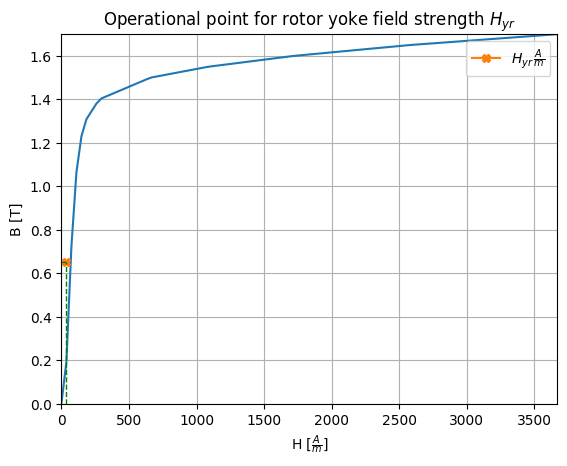

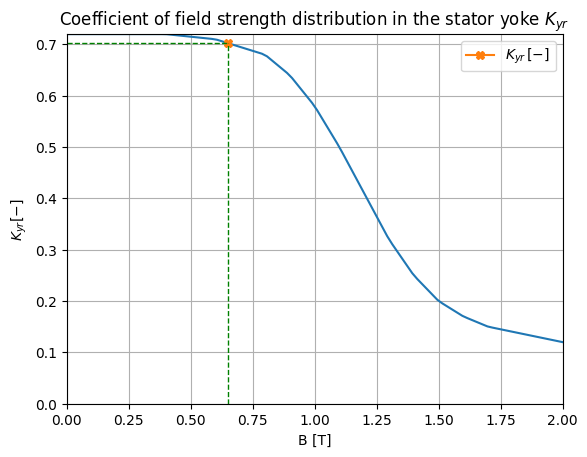

In [16]:
# Rotor MMF drop
D_r = D_r = D-2*(delta+h_m)
display(Latex(rf'$D_{{r}} =  {D_r}\,\mathrm{{m}}$'))

h_yr = round((D_r-D_i)/2,4)
display(Latex(rf'$h_{{ys}} =  {h_ys}\,\mathrm{{m}}$'))

B_yr = round(Phi_m/(2*k_fe*h_yr*l),2)
display(Latex(rf'$B_{{yr}} =  {B_yr}\,\mathrm{{T}}$'))

res = np.where(np.sign(B_yr-B_interp[:-1]) != np.sign(B_yr-B_interp[1:]))[0]
H_yr = round(H_interp[res[0]],2)
display(Latex(rf'$H_{{yr}} =  {H_yr}\,\mathrm{{\frac{{A}}{{m}}}}$'))

K_yr = Ky_from_B(B_yr)
display(Latex(rf'$K_{{yr}} =  {K_yr}$'))

l_yr = round(((D_i+h_yr)*math.pi)/(2*p) + 0.6*h_yr,2)
display(Latex(rf'$l_{{yr}} =  {l_yr}\,\mathrm{{m}}$'))

V_yr = round(H_yr*l_yr*K_yr,2)
display(Latex(rf'$V_{{yr}} =  {V_yr}\,\mathrm{{A}}$'))

fig1, ax1 = plt.subplots()

ax1.plot(H_interp, B_interp)
ax1.set_xlim([0.0, max(H_interp)])
ax1.set_ylim([0.0, max(B_interp)])
ax1.set_xlabel(r"H [$\frac{A}{m}]$")
ax1.set_ylabel("B [T]")
ax1.grid()

ax1.plot(H_yr, B_yr, marker="X", label=r'$H_{yr} \, \frac{A}{m}$')
ax1.plot([0, H_yr], [B_yr, B_yr], linestyle="dashed", linewidth=1, color = "green")
ax1.plot([H_yr, H_yr], [0, B_yr], linestyle="dashed", linewidth=1, color = "green")

ax1.legend(loc = "best")
ax1.set_title("Operational point for rotor yoke field strength $H_{yr}$")

plt.show()



fig2, ax2 = plt.subplots()

ax2.plot(B_ky_interp, Ky_interp)
ax2.set_title("Coefficient of field strength distribution in the stator yoke $K_{yr}$")
ax2.set_xlim([0.0,max(B_ky_interp)])
ax2.set_ylim([0.0,max(Ky_interp)])
ax2.set_xlabel("B [T]")
ax2.set_ylabel("$K_{yr} [-]$")
ax2.grid()

ax2.plot(B_yr, K_yr, marker="X", label=r'$K_{yr} \, [-] $')
ax2.plot([0, B_yr], [K_yr, K_yr], linestyle="dashed", linewidth=1, color = "green")
ax2.plot([B_yr, B_yr], [0, K_yr], linestyle="dashed", linewidth=1, color = "green")

ax2.legend(loc = "best")
ax2.plot()
plt.show()


<h2> Total MMF drop </h2>

In [17]:
k_sat = 1 + (V_t + 0.5*V_ys + 0.5*V_yr)/V_delta
h_m_new = k_sat * k_c * delta * (mi_rm / (B_r / B_delta_m - 1))
h_m_old = 10
iteration = 0
while (abs(h_m_new - h_m_old)/h_m_new) > 0.01:
    h_m_old = h_m_new

    D_r = D - 2 * delta - 2 * h_m_old

    delta_kc = delta + h_m/mi_rm

    k_c = tau_s/(tau_s-(2*bo/math.pi)*(math.atan(bo/(2*delta_kc))-(delta_kc/bo)*math.log(1+(bo/(2*delta_kc))**2)))

    V_delta = B_delta_m * delta * k_c / mi_0

    h_yr = (D_r - D_i) / 2
    l_yr = (D_i + h_yr) * math.pi / (2 * p) + 0.6*h_yr
    V_yr = H_yr*l_yr*K_yr

    k_sat = 1 + (V_t + 0.5*V_ys + 0.5*V_yr)/V_delta
    h_m_new =  k_sat * k_c * delta * (mi_rm / (B_r / B_delta_m - 1))
    D_r = D - 2 * delta - 2 * h_m_new

    iteration += 1
    display(Latex(rf'$Number\, of \,iterations \,= \,{iteration} \,\, and\, difference\, is:\,{(abs(h_m_new - h_m_old)/h_m_new):.5f} $'))

h_m = h_m_new

display(Latex(rf'$h_{{m}} =  {h_m * 1e3}\,\mathrm{{mm}}$'))
display(Latex(rf'$D_{{r}} =  {D_r:.2f}\,\mathrm{{m}}$'))
display(Latex(rf'$k_{{c}} =  {k_c:.4f}\,$'))
display(Latex(rf'$V_{{\delta}} =  {V_delta:.2f}\,\mathrm{{A}}$'))
display(Latex(rf'$h_{{yr}} =  {h_yr:.3f}\, \mathrm{{m}}$'))
display(Latex(rf'$l_{{yr}} =  {l_yr:.3f}\,\mathrm{{m}}$'))
display(Latex(rf'$V_{{yr}} =  {V_yr:.2f}\,\mathrm{{A}}$'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<h1> LOSSES AND EFFICIENCY </h1>


<h2> Winding losses </h2>

In [33]:
sigma_copper = 41.66                  # TODO
A = 1.45                              # TODO
B = 30*1e-3                           # TODO
l_ew = round(A * math.pi * (D + hs) * y / Q_s + B, 4)
display(Latex(rf'$l_{{ew}} \, = {l_ew}\,\mathrm{{m}}$'))
R_theta = round((z_slot * Q_s * (l + l_ew)) / (sigma_copper * m * a**2 * q_c),4)
display(Latex(rf'$R_{{\theta}} \, = {R_theta}\,\mathrm{{\ohm}}$'))
P_Cu = round(3 * I**2 * R_theta , 2)
display(Latex(rf'$P_{{Cu}} \, = {P_Cu} \,W$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Core losses

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

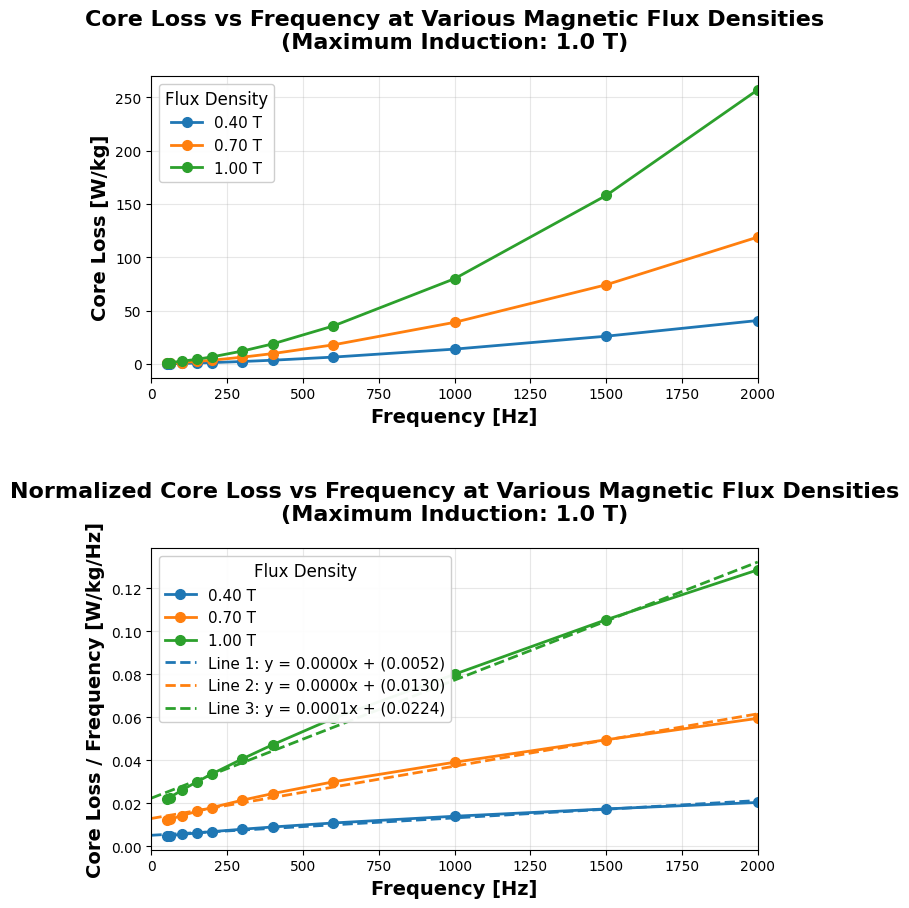

In [62]:
# Data for core losses calculation is taken from:
# https://ocw.mit.edu/courses/6-685-electric-machines-fall-2013/64bf1faf0a973d9607334321dd252794_MIT6_685F13_ps03data.pdf

flux_density_tesla = np.array([0.40, 0.70, 1.00])                                           # TODO

frequencies = np.array([50, 60, 100, 150, 200, 300, 400, 600, 1000, 1500, 2000])            # TODO

core_loss_w_per_kg = np.array([
    [0.240, 0.295, 0.555, 0.934, 1.37, 2.39, 3.60, 6.52, 14.0, 26.1, 40.8],   # 0.40 T
    [0.602, 0.749, 1.43, 2.44, 3.61, 6.44, 9.81, 18.0, 39.1, 74.3, 119],       # 0.70 T
    [1.09, 1.36, 2.61, 4.50, 6.74, 12.2, 18.9, 35.7, 80.0, 158, 257]           # 1.00 T
])                                                                                          # TODO


core_loss_normalized = core_loss_w_per_kg / frequencies

tmp = 0
N = np.shape(core_loss_normalized)[1]
number_of_curves = np.shape(flux_density_tesla)[0]
Dc_arr = np.array([])
Ec_arr = np.array([])
for i in range(number_of_curves):
    factor1 = (1/N)*np.sum(core_loss_normalized[i] * frequencies)
    factor2 = (1/N)*np.sum(frequencies)
    factor3 = (1/N)*np.sum(core_loss_normalized[i])
    factor4 = (1/N)*np.sum((frequencies**2))
    Ec = (factor1 - factor2*factor3) / (factor4 - factor2**2)
    Ec_arr = np.append(Ec_arr, Ec)
    tmp += Ec/(flux_density_tesla[i]**2)
    Dc = factor3 - Ec*factor2
    Dc_arr = np.append(Dc_arr, Dc)

    display(Latex(rf'$E_{i + 1} = \, {Ec :.5f}$'))
    display(Latex(rf'$D_{i + 1} = \, {Dc :.5f}$'))

k_e = (1/number_of_curves)*tmp


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# --- Subplot 1: Raw Core Loss ---
for i, flux in enumerate(flux_density_tesla):
    ax1.plot(frequencies, core_loss_w_per_kg[i],
             marker='o', linewidth=2, markersize=7,
             label=f'{flux:.2f} T', color=colors[i])

ax1.set_xlabel('Frequency [Hz]', fontsize=14, fontweight='bold')
ax1.set_ylabel('Core Loss [W/kg]', fontsize=14, fontweight='bold')
ax1.set_title('Core Loss vs Frequency at Various Magnetic Flux Densities\n(Maximum Induction: 1.0 T)',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, max(frequencies))
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(title='Flux Density', fontsize=11, title_fontsize=12,
           loc='best', framealpha=0.95)

# --- Subplot 2: Normalized Core Loss ---
lines = [
    (Ec_arr[0], Dc_arr[0], 'Line 1'),
    (Ec_arr[1], Dc_arr[1], 'Line 2'),
    (Ec_arr[2], Dc_arr[2], 'Line 3'),
]

x = np.linspace(0, 2000, 100)
for i, flux in enumerate(flux_density_tesla):
    ax2.plot(frequencies, core_loss_normalized[i],
             marker='o', linewidth=2, markersize=7,
             label=f'{flux:.2f} T', color=colors[i])

for i, (a, b, label) in enumerate(lines):
    y = a * x + b
    ax2.plot(x, y, linewidth=2, linestyle = '--', label=f'{label}: y = {a:.4f}x + ({b:.4f})', color=colors[i])


ax2.set_xlabel('Frequency [Hz]', fontsize=14, fontweight='bold')
ax2.set_ylabel('Core Loss / Frequency [W/kg/Hz]', fontsize=14, fontweight='bold')
ax2.set_title('Normalized Core Loss vs Frequency at Various Magnetic Flux Densities\n(Maximum Induction: 1.0 T)',
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlim(0, max(frequencies))
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(title='Flux Density', fontsize=11, title_fontsize=12,
           loc='best', framealpha=0.95)

fig.tight_layout(pad=4.0)
plt.show()

In [73]:
A_lin = np.array([[1 , math.log(flux_density_tesla[0]), flux_density_tesla[0]*math.log(flux_density_tesla[0])],
                  [1 , math.log(flux_density_tesla[1]), flux_density_tesla[1]*math.log(flux_density_tesla[1])],
                  [1 , math.log(flux_density_tesla[2]), flux_density_tesla[2]*math.log(flux_density_tesla[2])],
                  ])

B_lin = np.array([ [math.log(Dc_arr[0])],
                   [math.log(Dc_arr[1])],
                   [math.log(Dc_arr[2])],
                   ])

x = np.linalg.solve(A_lin, B_lin)

display(Latex(rf'$k_{{h}} = \, {k_e :.7f} \, \frac{{W}}{{kgHz^2T^2}}$'))
display(Latex(rf'$k_{{h}} = \, {math.exp(x[0][0]):.5f} \, \frac{{W}}{{kgT^{{\alpha(B_m)}} Hz}}$'))
display(Latex(rf'$a_{{h}} = \, {x[1][0]:.5f} $'))
display(Latex(rf'$b_{{h}} = \, {x[2][0]:.5f} \, T^{{-1}}$'))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

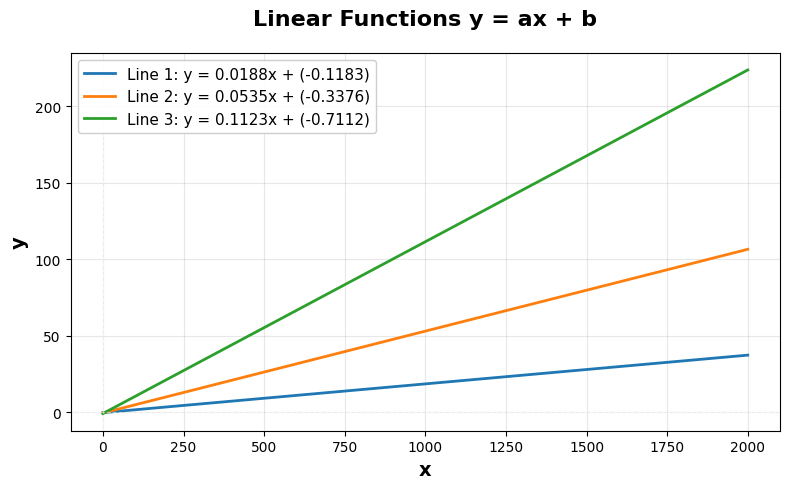

In [52]:
Ec_1 = 0.01878659111111111
Dc_1 = -0.11827433333333334
tmp  = 0.11741619444444443
Ec_2 = 0.05347548666666667
Dc_2 = -0.33758150000000003
Ec_3 = 0.11225664444444443
Dc_3 = -0.7112483333333333

x = np.linspace(0, 2000, 100)

lines = [
    (Ec_1, Dc_1, 'Line 1'),
    (Ec_2, Dc_2, 'Line 2'),
    (Ec_3, Dc_3, 'Line 3'),
]

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (a, b, label) in enumerate(lines):
    y = a * x + b
    ax.plot(x, y, linewidth=2, label=f'{label}: y = {a:.4f}x + ({b:.4f})', color=colors[i])

ax.set_xlabel('x', fontsize=14, fontweight='bold')
ax.set_ylabel('y', fontsize=14, fontweight='bold')
ax.set_title('Linear Functions y = ax + b', fontsize=16, fontweight='bold', pad=20)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

fig.tight_layout()
plt.show()

In [20]:

iter = 1
v = 1
n = 2
while (abs(Pc_old - Pc_new)/Pc_old) > 0.01:


    Pc_old = Pc_new
    Pc_new = 0


    B_delta_m_v = (4/math.pi) * (1/v) * B_delta_m * abs(math.sin(v * (alpha_m * math.pi / 180)/2  ))

    Psi_t_v = l * (D/2) * B_delta_m_v * ( 2 / (v*p) ) * abs(math.sin( v * p * math.pi / Q_s ))

    Psi_ys_v = l * (D/2) * B_delta_m_v * (1/ (v * p) )

    B_t_I_v = Psi_t_v / (k_fe * b_t_I * l)

    B_t_II_v_0 = Psi_t_v / (k_fe * b_t_II_0 * l)

    B_t_II_v_half = Psi_t_v / (k_fe * b_t_II_half * l)

    B_t_II_v_h_1 = Psi_t_v / (k_fe * b_t_II_h_1 * l)

    B_t_III_v = Psi_t_v / (k_fe * b_t_III * l)

    B_ysv = Psi_ys_v / (k_fe * h_ys * l)



    Pct_I = Kx_Fe*Q_s * (k_h * f * B_t_I**(a_h + b_h*B_t_I) + k_e * f**2 * (v * B_t_I_v)**2) * ro_c * k_fe * b_t_I * bo * l
    Pc_new += Pct_I

    Pct_II = Kx_Fe * Q_s * ro_c * k_fe * l * (h1 / 6) * ( (k_h * f * B_t_II_0 **(a_h + b_h*B_t_II_0) + k_e * f**2 * (v * B_t_II_v_0)**2 ) * b_t_II_0 + \
    4 * (k_h * f * B_t_II_half**(a_h + b_h*B_t_II_half) + k_e * f**2 * (v * B_t_II_v_half)**2 ) * b_t_II_half + \
    (k_h * f * B_t_II_h_1**(a_h + b_h*B_t_II_h_1) + k_e * f**2 * (v * B_t_II_v_h_1)**2 ) * b_t_II_h_1                                                      )
    Pc_new += Pct_II

    Pct_III = Kx_Fe * Q_s * (k_h * f * B_t_III**(a_h + b_h*B_t_III) + k_e * f**2 * (v * B_t_III_v)**2) * ro_c * k_fe * b_t_III * (h2 + h3) * l
    Pc_new += Pct_III

    P_cys = Kx_Fe * (k_h * f * B_ys**(a_h + b_h*B_ys) + k_e * f**2 * (v * B_ysv)**2) * ro_c * k_fe * (Do**2 - (D + 2 * hs)**2 ) * (math.pi / 4) * l
    Pc_new += P_cys


    P_total += Pct_I + Pct_II + Pct_III + P_cys

    print(f"In iteration {iter}. the difference was {(abs(Pc_old - Pc_new)/Pc_old) * 100} ")


    iter += 1

    n += 1

    v += 2

print(P_total)


NameError: name 'b_t_II_0' is not defined

# Magnet losses

In [ ]:
P_m_new = 100
P_m_old = 10
P_magnet_total = 0
sigma_m = 1 / (ro_magnet*1e-6*1e-2)
v = 1
N_seg_tan = 5
N_seg_ax = 5

b_m_seg = 3.25e-3#(alpha_m / N_seg_tan) * (D / (2 * p))
l_m_seg = 0.014286#l / N_seg_ax

while (abs(P_m_old - P_m_new)/P_m_old) > 0.01 and P_m_new > 0.0001:

    P_m_old = P_m_new

    u = b_o / (2 * delta) + math.sqrt(1 + (b_o / (2 * delta))**2 )
    beta = (1 + u**2 - 2*u) / (2 * (1 + u**2))
    bo_marked = ( delta * (b_o/delta)**2 ) / (beta * (5 + (b_o / delta) ) )
    alpha_1_v = 2 * math.sin( v * math.pi * bo_marked / tau_s ) / (v * math.pi * (1 - (v*bo_marked/tau_s)**2 ) )
    B_v = B_delta_m * beta * k_c * alpha_1_v
    tau_v = tau_s / (2 * v)

    f_mv = v*Q_s*n_r/60
    omega_mv = 2*math.pi*f_mv
    delta_mv = math.sqrt(2 / (omega_mv* mi_rm * mi_0 * sigma_m))


    if v == 1 and N_seg_ax >= l/delta_mv:
        raise ValueError("N_seg_ax > l/delta_mv, see script")

    if l_m_seg < delta_mv:
        raise ValueError("l_m_seg < delta_mv, see script")

    if b_m_seg > tau_v:
        Psi_mv = (2 / math.pi) * B_v * tau_v * l_m_seg
        E_mv = (1/math.sqrt(2)) * omega_mv * Psi_mv

        S_m_ax_v = (tau_v / 2) * (delta_mv / 2) * (1 - math.exp(-2*h_m / delta_mv))
        S_m_tan_v = delta_mv * (delta_mv / 2) * (1 - math.exp(-2*h_m / delta_mv))

        R_mv = (math.pi / 2) * ( 2 * (l_m_seg - delta_mv) / S_m_ax_v + 2*tau_v / S_m_tan_v ) * (1/sigma_m)
        Z_mv = math.sqrt(2)*R_mv
        I_mv = E_mv / Z_mv
        P_m_seg_v = E_mv * I_mv * math.cos(phi_v * math.pi/180)
        P_m_new = 2*p*(b_m_seg / tau_v) * N_seg_tan * N_seg_ax * P_m_seg_v


    else:
        Psi_mv = B_v * b_m_seg * l_m_seg
        E_mv = (1/math.sqrt(2)) * omega_mv * Psi_mv
        S_m_ax_v = (b_m_seg/2) * (delta_mv / 2) * (1 - math.exp(-2*h_m / delta_mv))
        S_m_tan_v = S_m_ax_v
        R_mv = 2*(l_m_seg/S_m_ax_v + b_m_seg/S_m_tan_v) * (1/sigma_m)
        Z_mv = math.sqrt(2)*R_mv
        I_mv = E_mv / Z_mv
        P_m_seg_v = E_mv * I_mv * math.cos(phi_v * math.pi/180)
        P_m_new = 2*p*N_seg_tan * N_seg_ax * P_m_seg_v

    P_magnet_total += P_m_new
    v += 2
    print(f"In iteration {v}. the difference was {(abs(P_m_old - P_m_new)/P_m_old) * 100} ")

print(P_magnet_total)




<h1> STATOR WINDING INDUCTANCES </h1>

<h2> Magnetizing inductance </h2>

In [ ]:
L_m = m * 2/(p * math.pi**2) * (w * f_w / a)**2 * tau_p * l * mi_0 / delta_double_marked
display(Latex(rf'$L_{{m}} = {L_m: .2e} \, H$'))


<h2> Leakage inductance

In [ ]:
k_sl = 3 * y / (m*q) - 1
display(Latex(rf'$k_{{sl}} = {round(k_sl, 2)}$'))

t1 = b2/bs
t2 = b1/b2
t12 = t2

k_t_1 = (4*t1**2 - t1**4 - 4 * math.log(t1) - 3 ) / (4 * (1 - t1) * (1 - t1**2)**2 )
k_t_2 = (4*t2**2 - t2**4 - 4 * math.log(t2) - 3 ) / (4 * (1 - t2) * (1 - t2**2)**2 )
k_t_12 = (t12**2 - 2 * math.log(t2) - 1) / (2 * (1 - t12) * (1 - t12**2) )

lambda_b = h3 * k_t_1 / bs + h2 / (b2 - b1) * math.log(b2/b1) + 0.1424 + 0.5 * math.asin(math.sqrt( 1 - (bo / b1 )**2 )) + ho / bo
lambda_t = h2 * k_t_2 / b2 + 0.1424 + 0.5 * math.asin(math.sqrt(1 - (bo / b1)**2 )) + ho / bo
lambda_tb = h2 * k_t_12 / b2 + 0.1424 + 0.5 * math.asin(math.sqrt( 1 - (bo / b1 )**2 ) ) + ho / bo
# Slot leakage
L_sigma_sl = mi_0 * 2 * l/ (4 * p * q)  * (w / a)**2 * (lambda_t + lambda_b + k_sl * lambda_tb)
display(Latex(rf'$L_{{\sigma sl}} = {L_sigma_sl: .2e}\, H$'))

lambda_tt = (0.25 + 0.75 * y / tau_p) * (5 * delta_triple_marked / bo) / ( 5 + 4 * delta_triple_marked / bo )
# Tooth tip leakage
L_sigma_tt = mi_0 * 2 / (p * q) * l * (w / a)**2 * lambda_tt
display(Latex(rf'$L_{{\sigma tt}} = {L_sigma_tt : .2e} \, H$'))
# Harmonic leakage
# It is required to generate the array of harmonics that will be used
ni = np.array([5,7,11,13,17,19])
sum_fw_ni = 0
# --------------------------------------
for v in ni:
    f_d_ni = math.sin(math.radians(q_dash*v*alfa_dash/2)) / (q_dash*math.sin(math.radians(v*alfa_dash/2)))
    f_p_ni = math.sin(v**math.pi*y/(tau_p*2))
    f_w_ni = f_p_ni*f_d_ni

    sum_fw_ni += (f_w_ni / v)**2

sigma_v = sum_fw_ni / f_w**2
L_sigma_v = L_m * sigma_v
display(Latex(rf'$L_{{\sigma v}} = {L_sigma_v:.2e}\, H$'))

# End winding leakage
l_ew = 0.0618
lambda_ew = 0.34 * q * (1 - 2*y*tau_p /(math.pi * m * q * l_ew) )
L_sigma_ew = mi_0 * 2 / (p * q) * (150 / a)**2 * l_ew * lambda_ew
display(Latex(rf'$L_{{\sigma ew}} = {L_sigma_ew: .2e} \, H$'))
#Total leakage inductance
L_sigma = L_sigma_sl + L_sigma_tt + L_sigma_v + L_sigma_ew
display(Latex(rf'$L_{{\sigma}} = {L_sigma: .2e} \, H$'))

#Total leakage reactance
X_sigma = L_sigma * 2 * math.pi * f
display(Latex(rf'$X_{{\sigma}} = {X_sigma: .2e} \, {{\ohm}}$'))

<h2> Synchronous reactance </h2>

In [ ]:
X_s = (L_m + L_sigma) * 2 * math.pi * f
display(Latex(rf'$X_{{s}} = {X_s: .2e} \, {{\ohm}}$'))

<h2> Rated voltage and power factor </h2>

In [ ]:
# Rated phase RMS voltage
U = math.sqrt((E + I*R)**2 + (I*X_s)**2)

# Line to line RMS voltage
U_l_l_calculated = math.sqrt(3) * U

#Check the initial required rated value with the calculated one
if (U_l_l_calculated - U_l_l) / U_l_l_calculated < 0.02:
    print("Motor is sufficient and does not need any modification")
    cos_phi = (E + I*R) / U
else:
    print("Motor needs to be recalculated")


